# EDA 14.2: Regional Behavior Analysis

This notebook analyzes regional behavior across return rate, delivery time, AOV, and logistics optimization signals, and previews leakage-safe regional aggregate features for total Revenue forecasting support.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files are reported and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['orders.csv', 'customers.csv', 'geography.csv', 'order_items.csv', 'shipments.csv', 'returns.csv', 'payments.csv', 'reviews.csv', 'sales.csv']
REQUIRED = {'orders.csv', 'customers.csv', 'geography.csv', 'order_items.csv', 'shipments.csv', 'returns.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
1,customers.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\cu...
2,geography.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\ge...
3,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,shipments.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sh...
5,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
6,payments.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...
7,reviews.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
8,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Required and Optional Files

Load all available inputs safely with pandas and display schema summaries.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
orders = data.get('orders')
customers = data.get('customers')
geography = data.get('geography')
order_items = data.get('order_items')
shipments = data.get('shipments')
returns = data.get('returns')
payments = data.get('payments')
reviews = data.get('reviews')
sales = data.get('sales')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
1,customers,True,121930,"customer_id, zip, city, signup_date, gender, a..."
2,geography,True,39948,"zip, city, region, district"
3,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
4,shipments,True,566067,"order_id, ship_date, delivery_date, shipping_fee"
5,returns,True,39939,"return_id, order_id, product_id, return_date, ..."
6,payments,True,646945,"order_id, payment_method, payment_value, insta..."
7,reviews,True,113551,"review_id, order_id, product_id, customer_id, ..."
8,sales,True,3833,"Date, Revenue, COGS"


## 3. Identify Key, Geography, Revenue, Delivery, Return, and Date Columns

Use tolerant matching for likely naming variations. Revenue is reconstructed from `order_items` if needed.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'customer_id': find_column(orders.columns, ['customer_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
        'zip': find_column(orders.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(orders.columns, ['city']),
        'region': find_column(orders.columns, ['region', 'state', 'province']),
        'order_value': find_column(orders.columns, ['order_total', 'revenue', 'sales_amount', 'amount', 'total', 'gmv'], contains=True),
    }

customer_cols = {}
if customers is not None:
    customer_cols = {
        'customer_id': find_column(customers.columns, ['customer_id']),
        'zip': find_column(customers.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(customers.columns, ['city']),
    }

geography_cols = {}
if geography is not None:
    geography_cols = {
        'zip': find_column(geography.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(geography.columns, ['city']),
        'region': find_column(geography.columns, ['region', 'state', 'province']),
        'district': find_column(geography.columns, ['district']),
    }

order_item_cols = {}
if order_items is not None:
    order_item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
        'amount': find_column(order_items.columns, ['revenue', 'item_total', 'line_total', 'sales_amount', 'net_sales'], contains=True),
    }

shipment_cols = {}
if shipments is not None:
    shipment_cols = {
        'order_id': find_column(shipments.columns, ['order_id']),
        'ship_date': find_column(shipments.columns, ['ship_date', 'shipment_date', 'shipped_date'], contains=True),
        'delivery_date': find_column(shipments.columns, ['delivery_date', 'delivered_date'], contains=True),
        'estimated_delivery_date': find_column(shipments.columns, ['estimated_delivery_date', 'eta', 'estimated_date'], contains=True),
    }

return_cols = {}
if returns is not None:
    return_cols = {
        'order_id': find_column(returns.columns, ['order_id']),
        'product_id': find_column(returns.columns, ['product_id']),
        'return_date': find_column(returns.columns, ['return_date', 'date'], contains=True),
        'return_quantity': find_column(returns.columns, ['return_quantity', 'quantity_returned', 'qty'], contains=True),
        'refund_amount': find_column(returns.columns, ['refund_amount', 'refund', 'refund_value'], contains=True),
    }

review_cols = {}
if reviews is not None:
    review_cols = {
        'order_id': find_column(reviews.columns, ['order_id']),
        'rating': find_column(reviews.columns, ['rating', 'score', 'stars'], contains=True),
        'review_date': find_column(reviews.columns, ['review_date', 'date'], contains=True),
    }

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date'], contains=True),
        'revenue': find_column(sales.columns, ['revenue', 'sales_amount', 'total_revenue'], contains=True),
    }

identified = pd.DataFrame({
    'orders': pd.Series(orders_cols),
    'customers': pd.Series(customer_cols),
    'geography': pd.Series(geography_cols),
    'order_items': pd.Series(order_item_cols),
    'shipments': pd.Series(shipment_cols),
    'returns': pd.Series(return_cols),
    'reviews': pd.Series(review_cols),
    'sales': pd.Series(sales_cols),
})
display(identified)

,orders,customers,geography,order_items,shipments,returns,reviews,sales
amount,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
city,None,city,city,NaN,NaN,NaN,NaN,NaN
customer_id,customer_id,customer_id,NaN,NaN,NaN,NaN,NaN,NaN
date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Date
delivery_date,NaN,NaN,NaN,NaN,delivery_date,NaN,NaN,NaN
discount,NaN,NaN,NaN,discount_amount,NaN,NaN,NaN,NaN
district,NaN,NaN,district,NaN,NaN,NaN,NaN,NaN
estimated_delivery_date,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
order_date,order_date,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,order_id,NaN,NaN,order_id,order_id,order_id,order_id,NaN


## 4. Build Order-Level Revenue and AOV Dataset

Start from `orders` and reconstruct `order_revenue` from `order_items` when the order table does not expose a reliable total.

In [4]:
regional_warnings = []
orders_clean = None
order_base = pd.DataFrame()

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['customer_id_std'] = orders_clean[orders_cols['customer_id']] if orders_cols.get('customer_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['order_status_std'] = orders_clean[orders_cols['order_status']].astype(str).str.strip().str.lower() if orders_cols.get('order_status') else pd.NA
    orders_clean['zip_std'] = orders_clean[orders_cols['zip']] if orders_cols.get('zip') else pd.NA
    orders_clean['city_order_std'] = orders_clean[orders_cols['city']] if orders_cols.get('city') else pd.NA
    orders_clean['region_order_std'] = orders_clean[orders_cols['region']] if orders_cols.get('region') else pd.NA
    orders_clean['order_revenue_raw'] = pd.to_numeric(orders_clean[orders_cols['order_value']], errors='coerce') if orders_cols.get('order_value') else np.nan

if order_items is not None and order_item_cols.get('order_id'):
    oi = order_items.copy()
    oi['order_id_std'] = oi[order_item_cols['order_id']]
    if order_item_cols.get('amount'):
        oi['item_revenue_std'] = pd.to_numeric(oi[order_item_cols['amount']], errors='coerce')
    else:
        qty = pd.to_numeric(oi[order_item_cols['quantity']], errors='coerce') if order_item_cols.get('quantity') else np.nan
        price = pd.to_numeric(oi[order_item_cols['price']], errors='coerce') if order_item_cols.get('price') else np.nan
        discount = pd.to_numeric(oi[order_item_cols['discount']], errors='coerce').fillna(0) if order_item_cols.get('discount') else 0
        oi['item_revenue_std'] = qty * price
    order_item_rev = oi.groupby('order_id_std').agg(
        order_revenue=('item_revenue_std', 'sum'),
        item_line_count=('order_id_std', 'size'),
    ).reset_index()
else:
    order_item_rev = pd.DataFrame(columns=['order_id_std', 'order_revenue', 'item_line_count'])

if orders_clean is not None:
    order_base = orders_clean.merge(order_item_rev, on='order_id_std', how='left', indicator='item_merge')
    if order_base['order_revenue_raw'].notna().sum() > 0:
        order_base['order_revenue'] = order_base['order_revenue_raw'].fillna(order_base['order_revenue'])
        revenue_source = f"orders.{orders_cols['order_value']}"
    else:
        revenue_source = 'order_items reconstructed revenue'
    order_base['order_count'] = 1

    quality = pd.DataFrame([{
        'revenue_source': revenue_source,
        'orders_with_missing_revenue': int(order_base['order_revenue'].isna().sum()),
        'zero_or_negative_revenue_orders': int(order_base['order_revenue'].fillna(0).le(0).sum()),
        'order_items_matched_to_orders': int((order_base['item_merge'] == 'both').sum()),
        'order_items_unmatched_to_orders': int((~order_item_rev['order_id_std'].isin(orders_clean['order_id_std'])).sum()) if len(order_item_rev) else 0,
    }])
    display(quality)
    if quality.loc[0, 'orders_with_missing_revenue'] > 0:
        regional_warnings.append(f"{quality.loc[0, 'orders_with_missing_revenue']} orders have missing revenue")
    if quality.loc[0, 'zero_or_negative_revenue_orders'] > 0:
        regional_warnings.append(f"{quality.loc[0, 'zero_or_negative_revenue_orders']} orders have zero or negative revenue")

,revenue_source,orders_with_missing_revenue,zero_or_negative_revenue_orders,order_items_matched_to_orders,order_items_unmatched_to_orders
0,order_items reconstructed revenue,0,0,646945,0


## 5. Attach Geography to Orders

Join to `customers` if needed, then to `geography` using ZIP/postal code. Region is the preferred geographic level.

In [5]:
orders_geo = pd.DataFrame()

if customers is not None:
    customers_clean = customers.copy()
    customers_clean['customer_id_std'] = customers_clean[customer_cols['customer_id']] if customer_cols.get('customer_id') else pd.NA
    customers_clean['zip_customer_std'] = customers_clean[customer_cols['zip']] if customer_cols.get('zip') else pd.NA
    customers_clean['city_customer_std'] = customers_clean[customer_cols['city']] if customer_cols.get('city') else pd.NA
else:
    customers_clean = None

if geography is not None:
    geography_clean = geography.copy()
    geography_clean['zip_geo_std'] = geography_clean[geography_cols['zip']] if geography_cols.get('zip') else pd.NA
    geography_clean['city_geo_std'] = geography_clean[geography_cols['city']] if geography_cols.get('city') else pd.NA
    geography_clean['region_geo_std'] = geography_clean[geography_cols['region']] if geography_cols.get('region') else pd.NA
    geography_clean['district_geo_std'] = geography_clean[geography_cols['district']] if geography_cols.get('district') else pd.NA
    geography_clean = geography_clean.drop_duplicates(subset=['zip_geo_std'])
else:
    geography_clean = None

if not order_base.empty:
    orders_geo = order_base.copy()
    if customers_clean is not None and 'customer_id_std' in orders_geo.columns:
        orders_geo = orders_geo.merge(
            customers_clean[['customer_id_std', 'zip_customer_std', 'city_customer_std']],
            on='customer_id_std',
            how='left',
            indicator='customer_merge'
        )
    else:
        orders_geo['customer_merge'] = 'left_only'

    orders_geo['zip_join'] = orders_geo['zip_std'].fillna(orders_geo.get('zip_customer_std'))
    if geography_clean is not None:
        orders_geo = orders_geo.merge(
            geography_clean[['zip_geo_std', 'city_geo_std', 'region_geo_std', 'district_geo_std']],
            left_on='zip_join',
            right_on='zip_geo_std',
            how='left',
            indicator='geo_merge'
        )
    else:
        orders_geo['geo_merge'] = 'left_only'

    orders_geo['city_std'] = orders_geo['city_order_std'].fillna(orders_geo.get('city_customer_std')).fillna(orders_geo.get('city_geo_std'))
    orders_geo['region_std'] = orders_geo['region_order_std'].fillna(orders_geo.get('region_geo_std'))
    orders_geo['city_std'] = orders_geo['city_std'].astype(str).str.strip()
    orders_geo['region_std'] = orders_geo['region_std'].astype(str).str.strip()
    orders_geo.loc[orders_geo['city_std'].isin(['nan', 'None', '']), 'city_std'] = np.nan
    orders_geo.loc[orders_geo['region_std'].isin(['nan', 'None', '']), 'region_std'] = np.nan

    join_quality = pd.DataFrame([{
        'orders_matched_to_customers': int((orders_geo['customer_merge'] == 'both').sum()),
        'rows_matched_to_geography': int((orders_geo['geo_merge'] == 'both').sum()),
        'rows_unmatched_to_geography': int((orders_geo['geo_merge'] == 'left_only').sum()),
        'missing_region_after_joins': int(orders_geo['region_std'].isna().sum()),
    }])
    display(join_quality)
    if join_quality.loc[0, 'missing_region_after_joins'] > 0:
        regional_warnings.append(f"{join_quality.loc[0, 'missing_region_after_joins']} orders still have missing region after joins")

,orders_matched_to_customers,rows_matched_to_geography,rows_unmatched_to_geography,missing_region_after_joins
0,646945,646945,0,0


## 6. Build Regional Return Metrics

Match returns to orders using exact `order_id` and create region-level return and refund summaries.

C:\Users\ACER\AppData\Local\Temp\ipykernel_5404\283992797.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  order_return['has_return'] = order_return['has_return'].fillna(False)


,region_std,total_orders,returned_orders,returned_quantity,refund_amount,total_revenue,return_rate,refund_to_revenue_ratio
2,West,167642,9495,"30,047.0000","123,729,660.1900","3,851,035,437.6500",0.0566,0.0321
0,Central,184691,10260,"30,553.0000","151,387,098.3800","4,941,908,471.6800",0.0556,0.0306
1,East,294612,16307,"48,986.0000","235,481,747.9800","7,637,532,676.2000",0.0554,0.0308


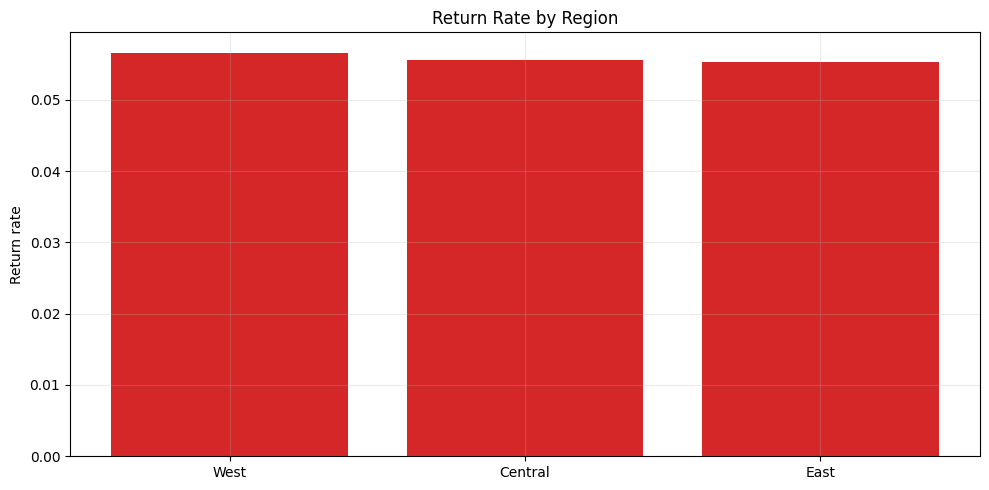

In [6]:
regional_returns = pd.DataFrame()

if not orders_geo.empty and returns is not None and return_cols.get('order_id'):
    ret = returns.copy()
    ret['order_id_std'] = ret[return_cols['order_id']]
    ret['return_quantity_std'] = pd.to_numeric(ret[return_cols['return_quantity']], errors='coerce') if return_cols.get('return_quantity') else np.nan
    ret['refund_amount_std'] = pd.to_numeric(ret[return_cols['refund_amount']], errors='coerce') if return_cols.get('refund_amount') else np.nan
    ret_agg = ret.groupby('order_id_std').agg(
        return_count=('order_id_std', 'size'),
        returned_quantity=('return_quantity_std', 'sum'),
        refund_amount=('refund_amount_std', 'sum'),
    ).reset_index()
    ret_agg['has_return'] = True

    order_return = orders_geo.merge(ret_agg, on='order_id_std', how='left')
    order_return['has_return'] = order_return['has_return'].fillna(False)
    order_return['returned_quantity'] = order_return['returned_quantity'].fillna(0)
    order_return['refund_amount'] = order_return['refund_amount'].fillna(0)

    regional_returns = order_return.groupby('region_std').agg(
        total_orders=('order_count', 'sum'),
        returned_orders=('has_return', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        total_revenue=('order_revenue', 'sum'),
    ).reset_index()
    regional_returns['return_rate'] = regional_returns['returned_orders'] / regional_returns['total_orders']
    regional_returns['refund_to_revenue_ratio'] = np.where(regional_returns['total_revenue'] > 0, regional_returns['refund_amount'] / regional_returns['total_revenue'], np.nan)
    regional_returns = regional_returns.sort_values('return_rate', ascending=False)
    display(regional_returns)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(regional_returns['region_std'].astype(str), regional_returns['return_rate'], color='tab:red')
    ax.set_title('Return Rate by Region')
    ax.set_ylabel('Return rate')
    plt.tight_layout()
    plt.show()
else:
    print('Regional return metrics could not be built because returns or geography linkage is unavailable.')

## 7. Build Regional Delivery Metrics

Match shipments to orders using exact `order_id`, compute delivery duration, and define late delivery using a data-driven threshold when ETA is unavailable.

,late_delivery_definition
0,Late delivery uses delivery_days above the 75t...


,region_std,shipment_count,avg_delivery_days,median_delivery_days,p90_delivery_days,late_delivery_ratio
2,West,167642,4.4997,5.0000,7.0000,0.1451
1,East,294612,4.4993,4.0000,7.0000,0.1457
0,Central,184691,4.4986,4.0000,7.0000,0.1454


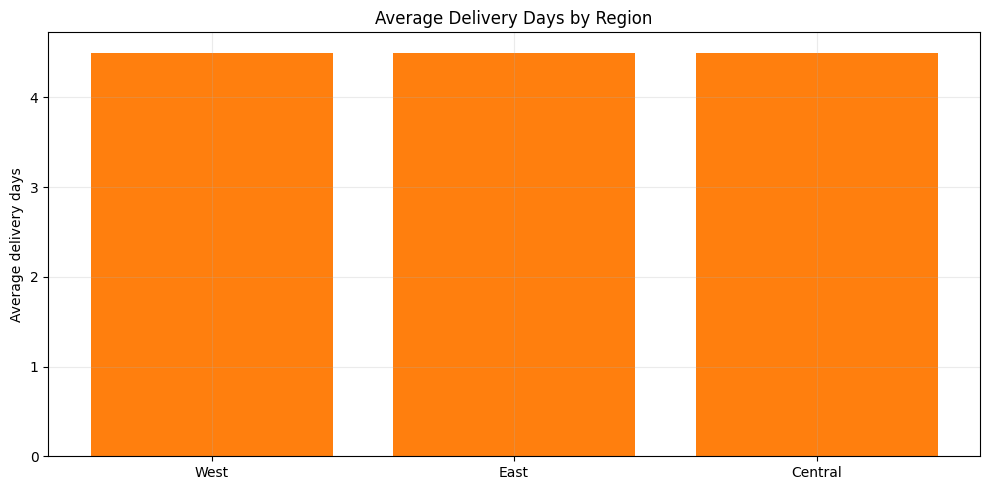

In [7]:
regional_delivery = pd.DataFrame()
delivery_base = pd.DataFrame()

if not orders_geo.empty and shipments is not None and shipment_cols.get('order_id'):
    shp = shipments.copy()
    shp['order_id_std'] = shp[shipment_cols['order_id']]
    shp['ship_date_std'] = pd.to_datetime(shp[shipment_cols['ship_date']], errors='coerce') if shipment_cols.get('ship_date') else pd.NaT
    shp['delivery_date_std'] = pd.to_datetime(shp[shipment_cols['delivery_date']], errors='coerce') if shipment_cols.get('delivery_date') else pd.NaT
    shp['estimated_delivery_date_std'] = pd.to_datetime(shp[shipment_cols['estimated_delivery_date']], errors='coerce') if shipment_cols.get('estimated_delivery_date') else pd.NaT

    delivery_base = orders_geo.merge(shp[['order_id_std', 'ship_date_std', 'delivery_date_std', 'estimated_delivery_date_std']], on='order_id_std', how='left')
    delivery_base['delivery_days_from_ship'] = (delivery_base['delivery_date_std'] - delivery_base['ship_date_std']).dt.days
    delivery_base['delivery_days_from_order'] = (delivery_base['delivery_date_std'] - delivery_base['order_date_std']).dt.days
    delivery_base['delivery_days'] = delivery_base['delivery_days_from_ship'].fillna(delivery_base['delivery_days_from_order'])

    if shipment_cols.get('estimated_delivery_date') and delivery_base['estimated_delivery_date_std'].notna().any():
        delivery_base['delivery_delay_days'] = (delivery_base['delivery_date_std'] - delivery_base['estimated_delivery_date_std']).dt.days
        delivery_base['is_late_delivery'] = delivery_base['delivery_delay_days'] > 0
        late_note = 'Late delivery uses delivered_date > estimated_delivery_date.'
    else:
        late_threshold = delivery_base['delivery_days'].dropna().quantile(0.75)
        delivery_base['is_late_delivery'] = delivery_base['delivery_days'] > late_threshold
        late_note = f'Late delivery uses delivery_days above the 75th percentile ({late_threshold:.2f}) because no ETA field is available.'
    display(pd.DataFrame([{'late_delivery_definition': late_note}]))

    invalid_delivery = int(delivery_base['delivery_days'].dropna().lt(0).sum())
    if invalid_delivery > 0:
        regional_warnings.append(f'{invalid_delivery} rows have negative delivery duration')

    regional_delivery = delivery_base.groupby('region_std').agg(
        shipment_count=('order_id_std', 'size'),
        avg_delivery_days=('delivery_days', 'mean'),
        median_delivery_days=('delivery_days', 'median'),
        p90_delivery_days=('delivery_days', lambda s: s.quantile(0.90)),
        late_delivery_ratio=('is_late_delivery', 'mean'),
    ).reset_index().sort_values('avg_delivery_days', ascending=False)
    display(regional_delivery)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(regional_delivery['region_std'].astype(str), regional_delivery['avg_delivery_days'], color='tab:orange')
    ax.set_title('Average Delivery Days by Region')
    ax.set_ylabel('Average delivery days')
    plt.tight_layout()
    plt.show()
else:
    print('Regional delivery metrics could not be built because shipment linkage is unavailable.')

## 8. Build Regional AOV and Revenue Metrics

Calculate Revenue, order count, AOV, median order value, and customer-level contribution by region.

,region_std,total_revenue,order_count,AOV,median_order_value,customer_count,revenue_per_customer
0,Central,"4,941,908,471.6800",184691,"26,757.7114","19,361.1600",30784,"160,534.9685"
1,East,"7,637,532,676.2000",294612,"25,924.0380","18,792.1350",44721,"170,781.7955"
2,West,"3,851,035,437.6500",167642,"22,971.7818","16,472.1100",14741,"261,246.5530"


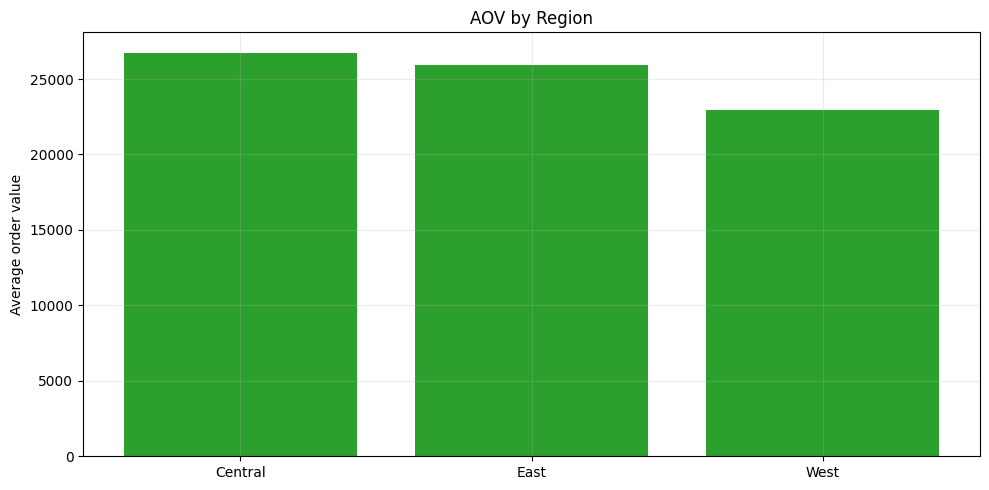

In [8]:
regional_aov = pd.DataFrame()

if not orders_geo.empty and orders_geo['region_std'].notna().any():
    regional_aov = orders_geo.groupby('region_std').agg(
        total_revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
        AOV=('order_revenue', 'mean'),
        median_order_value=('order_revenue', 'median'),
        customer_count=('customer_id_std', 'nunique'),
    ).reset_index()
    regional_aov['revenue_per_customer'] = np.where(regional_aov['customer_count'] > 0, regional_aov['total_revenue'] / regional_aov['customer_count'], np.nan)
    regional_aov = regional_aov.sort_values('AOV', ascending=False)
    display(regional_aov)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(regional_aov['region_std'].astype(str), regional_aov['AOV'], color='tab:green')
    ax.set_title('AOV by Region')
    ax.set_ylabel('Average order value')
    plt.tight_layout()
    plt.show()
else:
    print('Regional AOV metrics are unavailable because region could not be linked reliably.')

## 9. Regional Logistics Optimization Matrix

Combine Revenue, AOV, return, and delivery metrics into a heuristic regional priority view for logistics review.

,region_std,total_revenue,order_count,AOV,median_order_value,customer_count,revenue_per_customer,return_rate,refund_to_revenue_ratio,avg_delivery_days,p90_delivery_days,late_delivery_ratio,logistics_priority_flag
1,East,"7,637,532,676.2000",294612,"25,924.0380","18,792.1350",44721,"170,781.7955",0.0554,0.0308,4.4993,7.0000,0.1457,True
0,Central,"4,941,908,471.6800",184691,"26,757.7114","19,361.1600",30784,"160,534.9685",0.0556,0.0306,4.4986,7.0000,0.1454,False
2,West,"3,851,035,437.6500",167642,"22,971.7818","16,472.1100",14741,"261,246.5530",0.0566,0.0321,4.4997,7.0000,0.1451,False


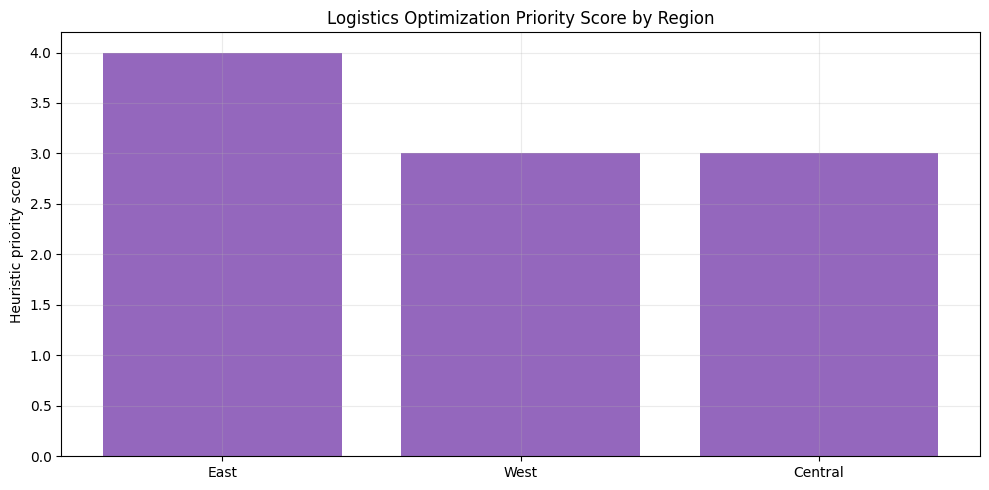

In [9]:
regional_matrix = pd.DataFrame()

if not regional_aov.empty:
    regional_matrix = regional_aov.merge(regional_returns[['region_std', 'return_rate', 'refund_to_revenue_ratio']], on='region_std', how='left') if not regional_returns.empty else regional_aov.copy()
    regional_matrix = regional_matrix.merge(regional_delivery[['region_std', 'avg_delivery_days', 'p90_delivery_days', 'late_delivery_ratio']], on='region_std', how='left') if not regional_delivery.empty else regional_matrix

    rev_threshold = regional_matrix['total_revenue'].quantile(0.75)
    order_threshold = regional_matrix['order_count'].quantile(0.75)
    delivery_threshold = regional_matrix['avg_delivery_days'].quantile(0.75) if 'avg_delivery_days' in regional_matrix.columns else np.nan
    late_threshold = regional_matrix['late_delivery_ratio'].quantile(0.75) if 'late_delivery_ratio' in regional_matrix.columns else np.nan
    return_threshold = regional_matrix['return_rate'].quantile(0.75) if 'return_rate' in regional_matrix.columns else np.nan

    regional_matrix['logistics_priority_flag'] = (
        regional_matrix['order_count'].ge(order_threshold)
        & (
            regional_matrix.get('avg_delivery_days', pd.Series(np.nan, index=regional_matrix.index)).ge(delivery_threshold)
            | regional_matrix.get('late_delivery_ratio', pd.Series(np.nan, index=regional_matrix.index)).ge(late_threshold)
            | regional_matrix.get('return_rate', pd.Series(np.nan, index=regional_matrix.index)).ge(return_threshold)
        )
    ) | (
        regional_matrix['total_revenue'].ge(rev_threshold)
        & regional_matrix.get('avg_delivery_days', pd.Series(np.nan, index=regional_matrix.index)).ge(delivery_threshold)
    )

    display(regional_matrix.sort_values(['logistics_priority_flag', 'total_revenue'], ascending=[False, False]))

    score = (
        regional_matrix['order_count'].rank(pct=True)
        + regional_matrix['total_revenue'].rank(pct=True)
        + regional_matrix.get('avg_delivery_days', pd.Series(0, index=regional_matrix.index)).rank(pct=True)
        + regional_matrix.get('late_delivery_ratio', pd.Series(0, index=regional_matrix.index)).rank(pct=True)
        + regional_matrix.get('return_rate', pd.Series(0, index=regional_matrix.index)).rank(pct=True)
    )
    regional_matrix['priority_score'] = score
    fig, ax = plt.subplots(figsize=(10, 5))
    ordered = regional_matrix.sort_values('priority_score', ascending=False)
    ax.bar(ordered['region_std'].astype(str), ordered['priority_score'], color='tab:purple')
    ax.set_title('Logistics Optimization Priority Score by Region')
    ax.set_ylabel('Heuristic priority score')
    plt.tight_layout()
    plt.show()

## 10. Relationship Analysis

Inspect region-level associations across delivery duration, return rate, and AOV. These are descriptive only.

,x,y,correlation
0,avg_delivery_days,return_rate,0.6756
1,AOV,return_rate,-0.9369
2,AOV,avg_delivery_days,-0.8906
3,late_delivery_ratio,return_rate,-0.9639


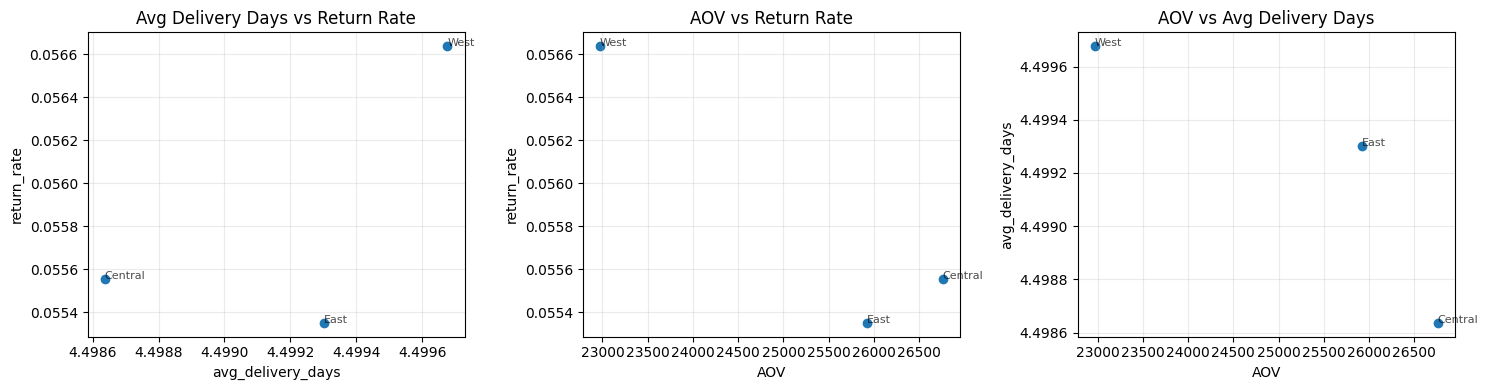

In [10]:
if not regional_matrix.empty and len(regional_matrix) >= 3:
    corr_rows = []
    pairs = [
        ('avg_delivery_days', 'return_rate'),
        ('AOV', 'return_rate'),
        ('AOV', 'avg_delivery_days'),
        ('late_delivery_ratio', 'return_rate'),
    ]
    for x, y in pairs:
        if x in regional_matrix.columns and y in regional_matrix.columns:
            corr_rows.append({'x': x, 'y': y, 'correlation': regional_matrix[x].corr(regional_matrix[y])})
    if corr_rows:
        display(pd.DataFrame(corr_rows))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plots = [
        ('avg_delivery_days', 'return_rate', 'Avg Delivery Days vs Return Rate'),
        ('AOV', 'return_rate', 'AOV vs Return Rate'),
        ('AOV', 'avg_delivery_days', 'AOV vs Avg Delivery Days'),
    ]
    for ax, (x, y, title) in zip(axes, plots):
        if x in regional_matrix.columns and y in regional_matrix.columns:
            ax.scatter(regional_matrix[x], regional_matrix[y], color='tab:blue')
            for row in regional_matrix.itertuples():
                ax.annotate(row.region_std, (getattr(row, x), getattr(row, y)), fontsize=8, alpha=0.7)
            ax.set_xlabel(x)
            ax.set_ylabel(y)
            ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 11. Regional Trends Over Time

Build monthly region-level Revenue, AOV, return rate, and delivery metrics and plot trends for top regions.

,month,region_std,revenue,order_count,AOV,avg_delivery_days,late_delivery_ratio,return_rate
0,2012-07-01,Central,"42,346,424.9200",1543,"27,444.2158",4.4412,0.1465,0.0493
1,2012-07-01,East,"61,481,999.6500",2542,"24,186.4672",4.4694,0.1467,0.0586
2,2012-07-01,West,"26,578,348.9400",1209,"21,983.7460",4.4853,0.1365,0.0538
3,2012-08-01,Central,"44,991,460.5700",1782,"25,247.7332",4.4948,0.1448,0.0550
4,2012-08-01,East,"77,151,645.6600",3088,"24,984.3412",4.5188,0.1448,0.0563
5,2012-08-01,West,"36,946,134.0800",1557,"23,729.0521",4.4873,0.1407,0.0520
6,2012-09-01,Central,"36,125,296.4600",1411,"25,602.6197",4.4442,0.1446,0.0574
7,2012-09-01,East,"62,461,116.0200",2446,"25,536.0245",4.5490,0.1521,0.0609
8,2012-09-01,West,"30,720,721.3400",1362,"22,555.5957",4.4344,0.1358,0.0661
9,2012-10-01,Central,"30,227,334.1700",1109,"27,256.3879",4.5886,0.1686,0.0658


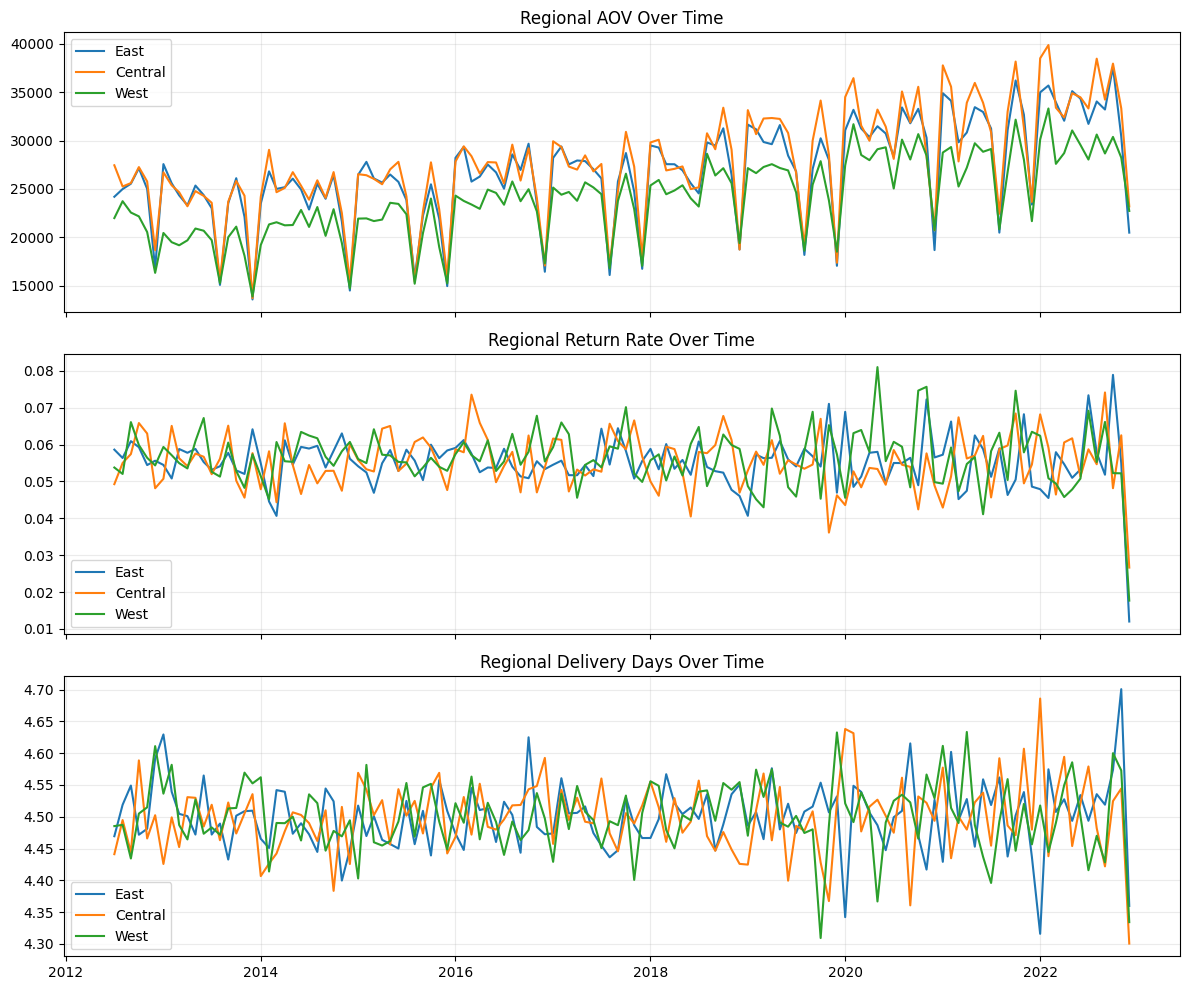

In [11]:
region_monthly = pd.DataFrame()

if not orders_geo.empty and orders_geo['order_date_std'].notna().any():
    orders_geo['month'] = orders_geo['order_date_std'].dt.to_period('M').dt.to_timestamp()
    region_revenue_monthly = orders_geo.groupby(['month', 'region_std']).agg(
        revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
        AOV=('order_revenue', 'mean'),
    ).reset_index()

    if not delivery_base.empty:
        delivery_monthly_base = delivery_base.copy()
        delivery_monthly_base['month'] = delivery_monthly_base['order_date_std'].dt.to_period('M').dt.to_timestamp()
        delivery_monthly = delivery_monthly_base.groupby(['month', 'region_std']).agg(
            avg_delivery_days=('delivery_days', 'mean'),
            late_delivery_ratio=('is_late_delivery', 'mean'),
        ).reset_index()
    else:
        delivery_monthly = pd.DataFrame(columns=['month', 'region_std', 'avg_delivery_days', 'late_delivery_ratio'])

    if not returns.empty and not orders_geo.empty:
        ret_monthly_base = orders_geo.merge(
            returns.assign(order_id_std=returns[return_cols['order_id']]).groupby('order_id_std').size().reset_index(name='return_count'),
            on='order_id_std',
            how='left'
        )
        ret_monthly_base['has_return'] = ret_monthly_base['return_count'].fillna(0) > 0
        return_monthly = ret_monthly_base.groupby(['month', 'region_std']).agg(
            return_rate=('has_return', 'mean')
        ).reset_index()
    else:
        return_monthly = pd.DataFrame(columns=['month', 'region_std', 'return_rate'])

    region_monthly = region_revenue_monthly.merge(delivery_monthly, on=['month', 'region_std'], how='left')
    region_monthly = region_monthly.merge(return_monthly, on=['month', 'region_std'], how='left')
    display(region_monthly.head(15))

    top_regions = regional_aov.sort_values('total_revenue', ascending=False).head(3)['region_std'].tolist() if not regional_aov.empty else []
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    for region in top_regions:
        tmp = region_monthly[region_monthly['region_std'] == region]
        axes[0].plot(tmp['month'], tmp['AOV'], label=region)
        axes[1].plot(tmp['month'], tmp['return_rate'], label=region)
        axes[2].plot(tmp['month'], tmp['avg_delivery_days'], label=region)
    axes[0].set_title('Regional AOV Over Time')
    axes[1].set_title('Regional Return Rate Over Time')
    axes[2].set_title('Regional Delivery Days Over Time')
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()

## 12. Optional Rating Context

If reviews can be linked by `order_id`, compare average rating by region and assess whether slower-delivery regions also show weaker ratings.

In [12]:
regional_rating = pd.DataFrame()

if not orders_geo.empty and reviews is not None and review_cols.get('order_id') and review_cols.get('rating'):
    rv = reviews.copy()
    rv['order_id_std'] = rv[review_cols['order_id']]
    rv['rating_std'] = pd.to_numeric(rv[review_cols['rating']], errors='coerce')
    rv_agg = rv.groupby('order_id_std').agg(avg_rating=('rating_std', 'mean')).reset_index()
    regional_rating = orders_geo.merge(rv_agg, on='order_id_std', how='inner').groupby('region_std').agg(
        avg_rating=('avg_rating', 'mean'),
        rated_orders=('order_id_std', 'size'),
    ).reset_index()
    display(regional_rating)

    if not regional_delivery.empty:
        rating_delivery = regional_delivery.merge(regional_rating, on='region_std', how='inner')
        if not rating_delivery.empty:
            print(f"Correlation between regional avg delivery days and avg rating: {rating_delivery['avg_delivery_days'].corr(rating_delivery['avg_rating']):.4f}")
else:
    print('Regional rating context is unavailable because review linkage is not reliable or not present.')

,region_std,avg_rating,rated_orders
0,Central,3.9452,31362
1,East,3.9375,50171
2,West,3.9249,29836


Correlation between regional avg delivery days and avg rating: -0.9555


## 13. Optional Validation Against sales.csv

Use `sales.csv` only as a daily aggregate validation source. It cannot be joined directly to geography unless it has a geographic key.

In [13]:
sales_validation = pd.DataFrame()

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue') and not orders_geo.empty and orders_geo['order_date_std'].notna().any():
    reconstructed_daily = orders_geo.groupby(orders_geo['order_date_std'].dt.floor('D')).agg(
        reconstructed_revenue=('order_revenue', 'sum')
    ).reset_index().rename(columns={'order_date_std': 'date'})

    sales_clean = sales.copy()
    sales_clean['date_std'] = pd.to_datetime(sales_clean[sales_cols['date']], errors='coerce')
    sales_clean['sales_revenue_std'] = pd.to_numeric(sales_clean[sales_cols['revenue']], errors='coerce')
    sales_daily = sales_clean.groupby('date_std').agg(sales_revenue=('sales_revenue_std', 'sum')).reset_index().rename(columns={'date_std': 'date'})

    sales_validation = reconstructed_daily.merge(sales_daily, on='date', how='inner')
    if not sales_validation.empty:
        sales_validation['difference'] = sales_validation['reconstructed_revenue'] - sales_validation['sales_revenue']
        display(pd.DataFrame([{
            'overlapping_days': len(sales_validation),
            'correlation': sales_validation['reconstructed_revenue'].corr(sales_validation['sales_revenue']),
            'total_difference': sales_validation['difference'].sum(),
            'mean_absolute_difference': sales_validation['difference'].abs().mean(),
        }]))
        print('sales.csv is used only for daily aggregate validation. It has no direct regional key in this dataset.')

,overlapping_days,correlation,total_difference,mean_absolute_difference
0,3833,1.0000,0.0000,0.0000


sales.csv is used only for daily aggregate validation. It has no direct regional key in this dataset.


## 14. Business Insight Discovery

Summarize practical regional behavior patterns that may support logistics, returns, inventory, or customer-experience actions.

In [14]:
if not regional_matrix.empty:
    high_return = regional_matrix.sort_values('return_rate', ascending=False).head(3) if 'return_rate' in regional_matrix.columns else pd.DataFrame()
    long_delivery = regional_matrix.sort_values('avg_delivery_days', ascending=False).head(3) if 'avg_delivery_days' in regional_matrix.columns else pd.DataFrame()
    high_aov = regional_matrix.sort_values('AOV', ascending=False).head(3)
    weak_ops = regional_matrix[regional_matrix['logistics_priority_flag']].sort_values('total_revenue', ascending=False)

    print('Highest return-rate regions')
    display(high_return)
    print('Longest delivery regions')
    display(long_delivery)
    print('Highest AOV regions')
    display(high_aov)
    print('High-Revenue regions with weaker logistics or return behavior')
    display(weak_ops)

Highest return-rate regions


,region_std,total_revenue,order_count,AOV,median_order_value,customer_count,revenue_per_customer,return_rate,refund_to_revenue_ratio,avg_delivery_days,p90_delivery_days,late_delivery_ratio,logistics_priority_flag,priority_score
2,West,"3,851,035,437.6500",167642,"22,971.7818","16,472.1100",14741,"261,246.5530",0.0566,0.0321,4.4997,7.0000,0.1451,False,3.0000
0,Central,"4,941,908,471.6800",184691,"26,757.7114","19,361.1600",30784,"160,534.9685",0.0556,0.0306,4.4986,7.0000,0.1454,False,3.0000
1,East,"7,637,532,676.2000",294612,"25,924.0380","18,792.1350",44721,"170,781.7955",0.0554,0.0308,4.4993,7.0000,0.1457,True,4.0000


Longest delivery regions


,region_std,total_revenue,order_count,AOV,median_order_value,customer_count,revenue_per_customer,return_rate,refund_to_revenue_ratio,avg_delivery_days,p90_delivery_days,late_delivery_ratio,logistics_priority_flag,priority_score
2,West,"3,851,035,437.6500",167642,"22,971.7818","16,472.1100",14741,"261,246.5530",0.0566,0.0321,4.4997,7.0000,0.1451,False,3.0000
1,East,"7,637,532,676.2000",294612,"25,924.0380","18,792.1350",44721,"170,781.7955",0.0554,0.0308,4.4993,7.0000,0.1457,True,4.0000
0,Central,"4,941,908,471.6800",184691,"26,757.7114","19,361.1600",30784,"160,534.9685",0.0556,0.0306,4.4986,7.0000,0.1454,False,3.0000


Highest AOV regions


,region_std,total_revenue,order_count,AOV,median_order_value,customer_count,revenue_per_customer,return_rate,refund_to_revenue_ratio,avg_delivery_days,p90_delivery_days,late_delivery_ratio,logistics_priority_flag,priority_score
0,Central,"4,941,908,471.6800",184691,"26,757.7114","19,361.1600",30784,"160,534.9685",0.0556,0.0306,4.4986,7.0000,0.1454,False,3.0000
1,East,"7,637,532,676.2000",294612,"25,924.0380","18,792.1350",44721,"170,781.7955",0.0554,0.0308,4.4993,7.0000,0.1457,True,4.0000
2,West,"3,851,035,437.6500",167642,"22,971.7818","16,472.1100",14741,"261,246.5530",0.0566,0.0321,4.4997,7.0000,0.1451,False,3.0000


High-Revenue regions with weaker logistics or return behavior


,region_std,total_revenue,order_count,AOV,median_order_value,customer_count,revenue_per_customer,return_rate,refund_to_revenue_ratio,avg_delivery_days,p90_delivery_days,late_delivery_ratio,logistics_priority_flag,priority_score
1,East,"7,637,532,676.2000",294612,"25,924.0380","18,792.1350",44721,"170,781.7955",0.0554,0.0308,4.4993,7.0000,0.1457,True,4.0000


## 15. Leakage-Safe Regional Feature Preview

Create lagged historical regional aggregate features only. These are optional supporting features for total Revenue forecasting, not direct predictors unless future region mix is known.

In [15]:
feature_preview = pd.DataFrame()

if not orders_geo.empty and orders_geo['order_date_std'].notna().any():
    daily_total = orders_geo.groupby(orders_geo['order_date_std'].dt.floor('D')).agg(
        total_revenue=('order_revenue', 'sum'),
        total_orders=('order_count', 'sum'),
    ).reset_index().rename(columns={'order_date_std': 'date'})

    daily_region = orders_geo.groupby([orders_geo['order_date_std'].dt.floor('D'), 'region_std']).agg(
        revenue=('order_revenue', 'sum'),
        orders=('order_count', 'sum'),
        AOV=('order_revenue', 'mean'),
    ).reset_index().rename(columns={'order_date_std': 'date'})

    if not returns.empty:
        ret_daily_base = orders_geo.merge(
            returns.assign(order_id_std=returns[return_cols['order_id']]).groupby('order_id_std').size().reset_index(name='return_count'),
            on='order_id_std',
            how='left'
        )
        ret_daily_base['has_return'] = ret_daily_base['return_count'].fillna(0) > 0
        daily_region_return = ret_daily_base.groupby([ret_daily_base['order_date_std'].dt.floor('D'), 'region_std']).agg(
            return_rate=('has_return', 'mean')
        ).reset_index().rename(columns={'order_date_std': 'date'})
    else:
        daily_region_return = pd.DataFrame(columns=['date', 'region_std', 'return_rate'])

    if not delivery_base.empty:
        daily_region_delivery = delivery_base.groupby([delivery_base['order_date_std'].dt.floor('D'), 'region_std']).agg(
            avg_delivery_days=('delivery_days', 'mean'),
            late_delivery_ratio=('is_late_delivery', 'mean')
        ).reset_index().rename(columns={'order_date_std': 'date'})
    else:
        daily_region_delivery = pd.DataFrame(columns=['date', 'region_std', 'avg_delivery_days', 'late_delivery_ratio'])

    mix_revenue = daily_region.groupby('date').apply(lambda d: d['revenue'].max() / d['revenue'].sum()).rename('top_region_revenue_share').reset_index()
    mix_conc = daily_region.groupby('date').apply(lambda d: (d['revenue'] / d['revenue'].sum()).pow(2).sum()).rename('region_mix_concentration').reset_index()
    top_region_orders = daily_region.groupby('date')['orders'].max().rename('top_region_order_count').reset_index()
    high_aov_region_share = daily_region.groupby('date').apply(lambda d: d.loc[d['AOV'] >= d['AOV'].quantile(0.75), 'revenue'].sum() / d['revenue'].sum()).rename('high_aov_region_share').reset_index()

    if not regional_matrix.empty and 'logistics_priority_flag' in regional_matrix.columns:
        high_risk_regions = regional_matrix.loc[regional_matrix['logistics_priority_flag'], 'region_std'].tolist()
    else:
        high_risk_regions = []
    high_risk_share = daily_region.groupby('date').apply(lambda d: d.loc[d['region_std'].isin(high_risk_regions), 'orders'].sum() / d['orders'].sum() if d['orders'].sum() > 0 else np.nan).rename('high_risk_region_order_share').reset_index()

    regional_return_rate_daily = daily_region_return.groupby('date')['return_rate'].mean().rename('regional_return_rate').reset_index() if not daily_region_return.empty else pd.DataFrame(columns=['date', 'regional_return_rate'])
    regional_delivery_days_daily = daily_region_delivery.groupby('date')['avg_delivery_days'].mean().rename('regional_avg_delivery_days').reset_index() if not daily_region_delivery.empty else pd.DataFrame(columns=['date', 'regional_avg_delivery_days'])
    regional_late_daily = daily_region_delivery.groupby('date')['late_delivery_ratio'].mean().rename('regional_late_delivery_ratio').reset_index() if not daily_region_delivery.empty else pd.DataFrame(columns=['date', 'regional_late_delivery_ratio'])
    regional_aov_daily = daily_region.groupby('date')['AOV'].mean().rename('regional_aov').reset_index()

    feat = daily_total.merge(regional_return_rate_daily, on='date', how='left')
    feat = feat.merge(regional_delivery_days_daily, on='date', how='left')
    feat = feat.merge(regional_late_daily, on='date', how='left')
    feat = feat.merge(regional_aov_daily, on='date', how='left')
    feat = feat.merge(mix_conc, on='date', how='left')
    feat = feat.merge(mix_revenue, on='date', how='left')
    feat = feat.merge(high_risk_share, on='date', how='left')
    feat = feat.merge(high_aov_region_share, on='date', how='left')
    feat = feat.merge(top_region_orders, on='date', how='left')

    feat['regional_return_rate_lag'] = feat['regional_return_rate'].shift(1)
    feat['regional_avg_delivery_days_lag'] = feat['regional_avg_delivery_days'].shift(1)
    feat['regional_late_delivery_ratio_lag'] = feat['regional_late_delivery_ratio'].shift(1)
    feat['regional_aov_lag'] = feat['regional_aov'].shift(1)
    feat['region_mix_concentration_lag'] = feat['region_mix_concentration'].shift(1)
    feat['top_region_revenue_share_lag'] = feat['top_region_revenue_share'].shift(1)
    feat['high_risk_region_order_share_lag'] = feat['high_risk_region_order_share'].shift(1)
    feat['high_aov_region_share_lag'] = feat['high_aov_region_share'].shift(1)
    feat['top_region_order_count_lag'] = feat['top_region_order_count'].shift(1)

    preview_cols = [
        'date', 'total_revenue', 'total_orders', 'regional_return_rate_lag',
        'regional_avg_delivery_days_lag', 'regional_late_delivery_ratio_lag',
        'regional_aov_lag', 'region_mix_concentration_lag',
        'top_region_revenue_share_lag', 'high_risk_region_order_share_lag',
        'high_aov_region_share_lag', 'top_region_order_count_lag'
    ]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('All regional features shown above are lagged historical aggregates only.')
print('These are optional supporting features for total daily Revenue forecasting, not direct features unless future regional mix is known.')
print('Do not use current-period or future regional behavior directly unless it is genuinely known before prediction.')

C:\Users\ACER\AppData\Local\Temp\ipykernel_5404\3257192768.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mix_revenue = daily_region.groupby('date').apply(lambda d: d['revenue'].max() / d['revenue'].sum()).rename('top_region_revenue_share').reset_index()


C:\Users\ACER\AppData\Local\Temp\ipykernel_5404\3257192768.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mix_conc = daily_region.groupby('date').apply(lambda d: (d['revenue'] / d['revenue'].sum()).pow(2).sum()).rename('region_mix_concentration').reset_index()


C:\Users\ACER\AppData\Local\Temp\ipykernel_5404\3257192768.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  high_aov_region_share = daily_region.groupby('date').apply(lambda d: d.loc[d['AOV'] >= d['AOV'].quantile(0.75), 'revenue'].sum() / d['revenue'].sum()).rename('high_aov_region_share').reset_index()


C:\Users\ACER\AppData\Local\Temp\ipykernel_5404\3257192768.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  high_risk_share = daily_region.groupby('date').apply(lambda d: d.loc[d['region_std'].isin(high_risk_regions), 'orders'].sum() / d['orders'].sum() if d['orders'].sum() > 0 else np.nan).rename('high_risk_region_order_share').reset_index()


,date,total_revenue,total_orders,regional_return_rate_lag,regional_avg_delivery_days_lag,regional_late_delivery_ratio_lag,regional_aov_lag,region_mix_concentration_lag,top_region_revenue_share_lag,high_risk_region_order_share_lag,high_aov_region_share_lag,top_region_order_count_lag
0,2012-07-04,"5,123,547.9400",162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",97,0.0688,4.3271,0.1482,"32,761.5652",0.3527,0.4217,0.4877,0.3511,79.0000
2,2012-07-06,"3,054,029.4200",93,0.0418,4.7769,0.1717,"29,183.8883",0.3411,0.3792,0.4330,0.2624,42.0000
3,2012-07-07,"2,667,930.9400",73,0.0945,4.3882,0.1506,"33,898.8059",0.4178,0.5471,0.6022,0.3155,56.0000
4,2012-07-08,"2,360,851.9000",88,0.1160,4.2752,0.0718,"33,154.5717",0.4664,0.6187,0.5205,0.6187,38.0000
5,2012-07-09,"3,548,386.4600",137,0.0816,4.3648,0.1278,"28,286.1203",0.3443,0.4117,0.4886,0.2641,43.0000
6,2012-07-10,"5,234,938.6200",183,0.0603,4.4362,0.1238,"25,169.1853",0.3970,0.5090,0.5036,0.3386,69.0000
7,2012-07-11,"5,582,884.7800",221,0.0444,4.2026,0.1298,"29,074.9370",0.3589,0.4394,0.4754,0.3462,87.0000
8,2012-07-12,"5,734,632.0200",246,0.0555,4.5671,0.1448,"25,036.3120",0.3714,0.4793,0.4751,0.3155,105.0000
9,2012-07-13,"5,309,511.7100",201,0.0363,4.3628,0.0978,"22,973.9406",0.3696,0.4461,0.4106,0.4461,101.0000


All regional features shown above are lagged historical aggregates only.
These are optional supporting features for total daily Revenue forecasting, not direct features unless future regional mix is known.
Do not use current-period or future regional behavior directly unless it is genuinely known before prediction.


## 16. Key Observations and Warnings

Summarize region-level return, delivery, AOV, logistics-priority, and feature-engineering takeaways.

In [16]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not regional_returns.empty:
    top_return = regional_returns.sort_values('return_rate', ascending=False).head(3)
    summary_lines.append('- Regions with highest return rate: ' + ', '.join(f"{r.region_std} ({r.return_rate:.2%})" for r in top_return.itertuples()) + '.')

if not regional_delivery.empty:
    top_delivery = regional_delivery.sort_values('avg_delivery_days', ascending=False).head(3)
    summary_lines.append('- Regions with longest delivery duration: ' + ', '.join(f"{r.region_std} ({r.avg_delivery_days:.2f} days)" for r in top_delivery.itertuples()) + '.')

if not regional_aov.empty:
    top_aov = regional_aov.sort_values('AOV', ascending=False).head(3)
    summary_lines.append('- Regions with highest AOV: ' + ', '.join(f"{r.region_std} ({r.AOV:,.2f})" for r in top_aov.itertuples()) + '.')

if not regional_matrix.empty:
    weak_regions = regional_matrix[regional_matrix['logistics_priority_flag']].sort_values('total_revenue', ascending=False).head(3)
    if not weak_regions.empty:
        summary_lines.append('- High-Revenue regions with weaker logistics or return behavior: ' + ', '.join(f"{r.region_std}" for r in weak_regions.itertuples()) + '.')
        summary_lines.append('- Regions that may need logistics optimization: ' + ', '.join(f"{r.region_std}" for r in weak_regions.itertuples()) + '.')

if not regional_matrix.empty and len(regional_matrix) >= 3 and 'avg_delivery_days' in regional_matrix.columns and 'return_rate' in regional_matrix.columns:
    corr = regional_matrix['avg_delivery_days'].corr(regional_matrix['return_rate'])
    relation = 'positively related' if corr > 0.1 else 'negatively related' if corr < -0.1 else 'weakly related'
    summary_lines.append(f'- Regional delivery and return behavior appear {relation} under simple correlation ({corr:.4f}).')

if regional_warnings:
    summary_lines.append('- Data quality warnings related to geography, delivery, returns, and Revenue: ' + '; '.join(regional_warnings))
else:
    summary_lines.append('- Data quality warnings related to geography, delivery, returns, and Revenue: none beyond the checks reported in notebook tables.')

summary_lines.append('- Optional leakage-safe regional aggregate features: regional_return_rate_lag, regional_avg_delivery_days_lag, regional_late_delivery_ratio_lag, regional_aov_lag, region_mix_concentration_lag, top_region_revenue_share_lag, high_risk_region_order_share_lag, and high_aov_region_share_lag.')
summary_lines.append('- Regional aggregate features are not direct features for total daily Revenue forecasting unless future regional mix is known.')
summary_lines.append('- Future regional behavior must not be used directly unless it is genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. Regional outcomes can vary with customer mix, logistics reach, assortment, promotions, and return policies.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Regions with highest return rate: West (5.66%), Central (5.56%), East (5.54%).
- Regions with longest delivery duration: West (4.50 days), East (4.50 days), Central (4.50 days).
- Regions with highest AOV: Central (26,757.71), East (25,924.04), West (22,971.78).
- High-Revenue regions with weaker logistics or return behavior: East.
- Regions that may need logistics optimization: East.
- Regional delivery and return behavior appear positively related under simple correlation (0.6756).
- Data quality warnings related to geography, delivery, returns, and Revenue: none beyond the checks reported in notebook tables.
- Optional leakage-safe regional aggregate features: regional_return_rate_lag, regional_avg_delivery_days_lag, regional_late_delivery_ratio_lag, regional_aov_lag, region_mix_concentration_lag, top_region_revenue_share_lag, high_risk_region_order_share_lag, and high_aov_region_share_lag.
- Regional aggregate features are not direct features for tot